# Attractive Hubbard BEC with pyALF

This notebook uses **pyALF** with the **Algorithm of Lattice Fermions (ALF)** to simulate the attractive Hubbard model and measure the on-site pair correlator directly.

$$N(\mathbf q)=\frac{1}{N}\sum_{i,j}e^{i\mathbf q\cdot(\mathbf r_i-\mathbf r_j)}\langle b_i^\dagger b_j\rangle,\qquad b_i^\dagger=c_{i\uparrow}^\dagger c_{i\downarrow}^\dagger.$$

The ALF source in this workspace has been extended with a native `Pair` observable. Its analyzed output is `Pair_eq_K`.

In [1]:
#TODO: 
#3. Better Markdown comments.
#6. Better Documentation

In [2]:
import matplotlib.pyplot as plt  # Plotting library
%matplotlib widget
import scienceplots
plt.style.use('science')

import numpy as np  # Numerical libary
from py_alf import ALF_source, Simulation, Lattice
from py_alf.ana import load_res  # Function for loading analysis results
from py_alf.utils import find_sim_dirs  # Function for finding QMC bins

from pathlib import Path
import pandas as pd
from collections import defaultdict

# Setting ALF directory

In [3]:
alf_dir = ALF_source(alf_dir=str(Path.cwd() / 'ALF'), branch="s-wave-Pairing_correlations")

Checking out branch s-wave-Pairing_correlations
Your branch is up to date with 'origin/s-wave-Pairing_correlations'.


Already on 's-wave-Pairing_correlations'


## Compile ALF

This cell compiles the modified Hubbard executable once. It does not run a simulation yet.
...


In [4]:
compile_sim = Simulation(alf_src=alf_dir, ham_name='Hubbard',sim_dict={}) #sim_dict is used to choose parameters.
compile_sim.compile()

Checking out branch s-wave-Pairing_correlations
Your branch is up to date with 'origin/s-wave-Pairing_correlations'.


Already on 's-wave-Pairing_correlations'


Compiling ALF... 
Cleaning up Prog/
Cleaning up Libraries/
Cleaning up Analysis/
Compiling Libraries


entanglement_mod.F90:35:2:

   35 | #warning "You are compiling entanglement without MPI. No Renyi entropy results possible, all other observables still work!"
      |  1~~~~~~
ar: creating archive modules_90.a
ar: creating archive libqrref.a


Compiling Analysis
Compiling Program
Compiling program modules
Parsing Hamiltonian parameters
filenames: Hamiltonians/Hamiltonian_Kondo_smod.F90 Hamiltonians/Hamiltonian_Kondo_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Hubbard_smod.F90 Hamiltonians/Hamiltonian_Hubbard_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Hubbard_Plain_Vanilla_smod.F90 Hamiltonians/Hamiltonian_Hubbard_Plain_Vanilla_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_tV_smod.F90 Hamiltonians/Hamiltonian_tV_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_LRC_smod.F90 Hamiltonians/Hamiltonian_LRC_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Z2_Matter_smod.F90 Hamiltonians/Hamiltonian_Z2_Matter_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Spin_Peierls_smod.F90 Hamiltonians/Hamiltonian_Spin_Peierls_read_write_parameters.F90
Link program
Done.


## Run the simulations

...

In [ ]:
LAT_SIZES = [4,6,8]
BETAS = [i for i in range(1,8)]

for beta in BETAS:
    for L in LAT_SIZES:
        sim = Simulation(
                    alf_dir, 'Hubbard',
                    {
                        ### Choice of Predefined Model###
                        'Model': 'Hubbard',
                        
                        ###Definition of the Lattice###
                        'Lattice_type': 'Square',
                        'L1': L,
                        'L2': L,
                        
                        #--- Model parameters ---#
                        'Beta': float(beta),
                        'ham_chem': 0.5,
                        'ham_U': -4.0,
                        #--- Simulation parameters --- #
                        'Nsweep': 10,
                        'NBin': 10,
                        'Mz': True, #Choice of HS-Transformation (Exclusive for Hubbard-type interactions); ALF-DOC: 8.3.2 M_Z-Hubbard interaction
                        'Checkerboard': True, #ALF-DOC: 2.3. The Trotter error and checkerboard decomposition
                        'Symm': True, #Symmetric Trotter decomposition; ALF-DOC: 2.3. The Trotter error and checkerboard decomposition

                        ###ALF Internal Flags###
                        'N_SUN': 2, #
                        'N_FL': 2, # 
                        'Ltau': 0, #Speed up simulation by not calculating time-displaced observables, which take more time to compute.
                    },
                    machine='GNU',
                    sim_dir=f'Attractive_Hubbard_L{L}_beta_{beta}'
                )
        sim.run()
        sim.analysis()
print('All simulations and analyses complete.')

Prepare directory "/Users/luis/Documents/_WORK/HELKE_TUTORIAL/ALF_data/Attractive_Hubbard_L4_beta_1" for Monte Carlo run.
Resuming previous run.
Run /Users/luis/Documents/_WORK/HELKE_TUTORIAL/ALF/Prog/ALF.out
 ALF Copyright (C) 2016 - 2022 The ALF project contributors
 This Program comes with ABSOLUTELY NO WARRANTY; for details see license.GPL
 This is free software, and you are welcome to redistribute it under certain conditions.
### Analyzing /Users/luis/Documents/_WORK/HELKE_TUTORIAL/ALF_data/Attractive_Hubbard_L4_beta_1 ###
/Users/luis/Documents/_WORK/HELKE_TUTORIAL
Scalar observables:
Ener_scal
Kin_scal
Part_scal
Pot_scal
Histogram observables:
Equal time observables:
Den_eq
Green_eq
Pair_eq
SpinT_eq
SpinXY_eq
SpinZ_eq
Time displaced observables:
Prepare directory "/Users/luis/Documents/_WORK/HELKE_TUTORIAL/ALF_data/Attractive_Hubbard_L6_beta_1" for Monte Carlo run.
Resuming previous run.
Run /Users/luis/Documents/_WORK/HELKE_TUTORIAL/ALF/Prog/ALF.out
 ALF Copyright (C) 2016 - 202

## Load $N(\mathbf q)$

...


In [ ]:
dirs = find_sim_dirs()
res=load_res(dirs)

./ALF_data/Attractive_Hubbard_L4_beta_1
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L4_beta_2
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L4_beta_3
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L4_beta_4
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L4_beta_5
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L4_beta_6
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L4_beta_7
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L6_beta_1
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L6_beta_2
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L6_beta_3
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L6_beta_4
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L6_beta_5
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L6_beta_6
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L6_beta_7
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L8_beta_1
No orbit

In [ ]:
def extract_pair_at_q(q: tuple, res: pd.DataFrame):
    plot_data = defaultdict(lambda: defaultdict(list))
    for idx in range(len(res)):
        latt = Lattice(res.iloc[idx]["Pair_eq_lattice"]) 
        q_idx = latt.k_to_n(q)
        pair_eq_k = np.squeeze(res.iloc[idx]["Pair_eqK"][...,q_idx])# squeeze because returned shape was (1,1,num_k) 
        pair_eq_k_err = np.squeeze(res.iloc[idx]["Pair_eqK_err"][...,q_idx]) # squeeze because returned shape was (1,1,num_k)
        L = res.iloc[idx]["l1"]
        beta = res.iloc[idx]["beta"]
        part_num_val = res.iloc[idx]["Part_scal0"]
        part_num_err = res.iloc[idx]["Part_scal0_err"]

        plot_data[f"L_{L}"]["beta"].append(beta)
        plot_data[f"L_{L}"]["pair_value"].append(pair_eq_k)
        plot_data[f"L_{L}"]["pair_err"].append(pair_eq_k_err)        
        plot_data[f"L_{L}"]["part_num_value"].append(part_num_val)
        plot_data[f"L_{L}"]["part_num_err"].append(part_num_err)
    return plot_data

In [ ]:
plot_data = extract_pair_at_q((0,0), res)

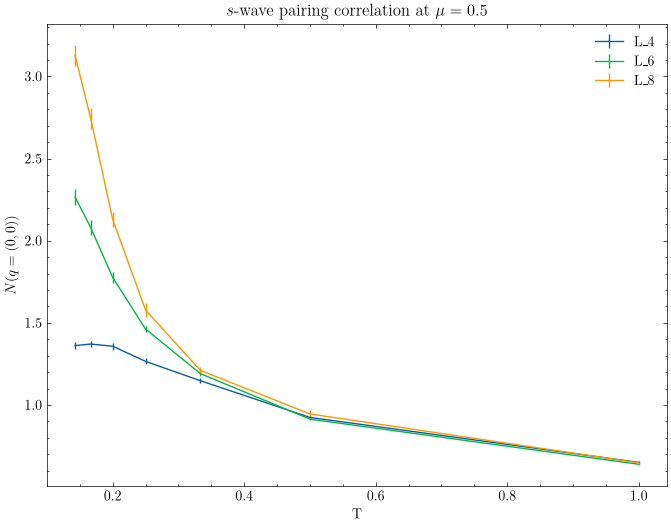

In [ ]:
#Plot Order parameter first
plt.figure(figsize=(8,6))
for L_key in plot_data.keys():
    T = [1/beta for beta in plot_data[L_key]["beta"]]
    data = plot_data[L_key]["pair_value"]
    err = plot_data[L_key]["pair_err"]
    plt.errorbar(T, data, yerr=err, label=L_key)
plt.title(r"$s$-wave pairing correlation at $\mu = 0.5$")
plt.xlabel(r"T")
plt.ylabel(r"$N(q=(0,0))$")
plt.legend()
plt.show()

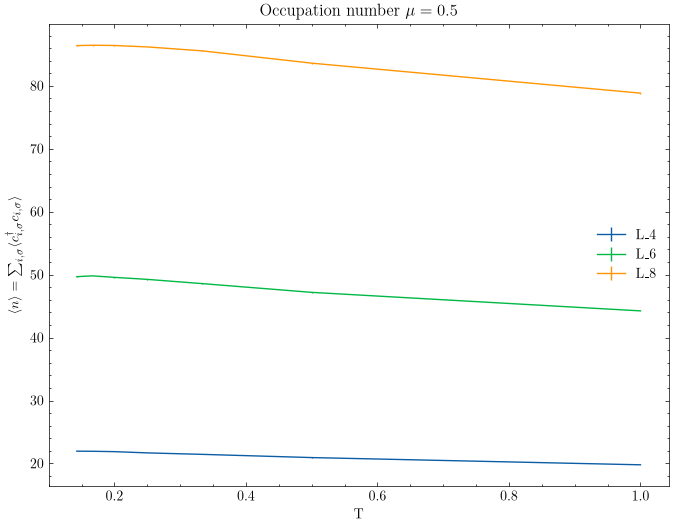

In [ ]:
#Plot Order parameter first

#Plot Order parameter first
plt.figure(figsize=(8,6))
for L_key in plot_data.keys():
    data = plot_data[L_key]["part_num_value"]
    err = plot_data[L_key]["part_num_err"]
    plt.errorbar(T, data, yerr=err, label=L_key)
    plt.title(r"Occupation number $\mu = 0.5$")
    plt.xlabel(r"T")
    plt.ylabel(r"$\langle n \rangle = \sum_{i,\sigma} \langle c^\dagger_{i,\sigma} c_{i,\sigma} \rangle$")
plt.legend()
plt.show()
